# Start Here

Welcome to the *Active Learning for bioacoustics* challenge.

This is an example notebook where you can evaluate your sampling method and export results for submissions. *You are free to adjust this notebook, however the results (.yaml) file must retain the correct format*.

Currently, this notebook runs the four baseline sampling strategies:
- `random` — random sampling (challenge baseline)
- `margin_multilabel` — uncertainty-based margin sampling
- `sklearn_coreset` — diversity-based coreset selection
- `sklearn_typiclust` — typicality clustering

**AULC** (Area Under the Learning Curve) for mAP (macro) is the primary metric:


In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import time

PROJECT_ROOT = Path().absolute().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.active_learner import ActiveLearner

core.active_learner - INFO - Pre-warming UMAP (triggering numba JIT compilation)...
core.active_learner - INFO - UMAP pre-warming completed in 6.098473072052002


## Step 1: Setup Configuration

In [2]:
# ---------------------------------------------------------------------------
# Active Learning Configuration
# ---------------------------------------------------------------------------

# Participant info:
AUTHOR_LASTNAME = 'baseline'      # NOTE: Lastname of the corresponding author
INSTITUTE_ABBREVIATION = 'BASEAL' # NOTE: Abbreviation of your institute or None

# AL loop parameters (Baseline default config)
N_CYCLES            = 15
EPOCHS_PER_CYCLE    = 10
BATCH_SIZE          = 32
N_SAMPLES_PER_CYCLE = 50    # NOTE: You can implement a scheduler

# Number of independent full-run repeats (each creates a fresh ActiveLearner
# with random model initialisation). Mean and SD are computed across these runs.
# NOTE: Submitted results must be run with N_REPEATS=5, use a lower value during development.
N_REPEATS = 1

# NOTE: Submitted results must be run with MAX_BUDGET=500.
MAX_BUDGET: int | None = None

# Warm-up samples before the AL loop (None = cold start)
PRETRAIN_SAMPLES: int | None = None

# Baseline strategies to compare. NOTE: When you are ready, add your sampling method here.
STRATEGIES = [
    "random",
    "margin_multilabel",
    "sklearn_coreset",
    "sklearn_typiclust",
]

print(f"Cycles            : {N_CYCLES}")
print(f"Samples per cycle : {N_SAMPLES_PER_CYCLE}")
print(f"Epochs per cycle  : {EPOCHS_PER_CYCLE}")
print(f"Outer repeats     : {N_REPEATS}  (independent runs, fresh model init each time)")
print(f"Max budget        : {MAX_BUDGET or 'none'}")
print(f"Strategies        : {STRATEGIES}")

Cycles            : 15
Samples per cycle : 50
Epochs per cycle  : 10
Outer repeats     : 1  (independent runs, fresh model init each time)
Max budget        : none
Strategies        : ['random', 'margin_multilabel', 'sklearn_coreset', 'sklearn_typiclust']


## Step 2: Dataset paths

Set paths for the dataset. Adjust for the BirdSet subsets (HSN, POW, UHH) or ATBFL dataset.

In [3]:
MODEL_NAME     = "birdnet"  # NOTE: Task 4 datasets will use "perch_v2" 
DATASET_NAME   = "ESC10_BASEAL"    # NOTE: download the Task 4 datasets and set the path e.g. "BirdSet_BASEAL/POW_BASEAL"

EMBEDDINGS_DIR = PROJECT_ROOT / DATASET_NAME / "embeddings" / MODEL_NAME
LABELS_PATH    = PROJECT_ROOT / DATASET_NAME / "labels.csv"

print(f"Embeddings : {EMBEDDINGS_DIR}")
print(f"Labels     : {LABELS_PATH}")
print(f"Dataset    : {DATASET_NAME}  |  Model: {MODEL_NAME}")

Embeddings : c:\Users\bmcewen\Documents\GitHub\BaseAL\ESC10_BASEAL\embeddings\birdnet
Labels     : c:\Users\bmcewen\Documents\GitHub\BaseAL\ESC10_BASEAL\labels.csv
Dataset    : ESC10_BASEAL  |  Model: birdnet


## Step 3: Run all baseline strategies

Each strategy runs the full AL loop with the shared configuration.
Results are collected in `results` for comparison and exported to `results/baselines/`.

In [4]:

results     = {}
all_learners = {}

OUTPUT_DIR = PROJECT_ROOT / "results" / "baselines"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_dataset_info_printed = False

for strategy in STRATEGIES:
    print(f"\n{'='*60}")
    print(f"Strategy: {strategy}")
    print(f"{'='*60}")

    strategy_histories = []  # one training_history list per repeat

    for rep in range(N_REPEATS):
        print(f"\n  -- Repeat {rep + 1}/{N_REPEATS} --")

        # Fresh ActiveLearner each repeat → random model re-initialisation.
        # repeats=1 disables the internal SD mechanism (handled by this outer loop).
        learner = ActiveLearner(
            embeddings_dir=EMBEDDINGS_DIR,
            annotations_path=LABELS_PATH,
            model_name=MODEL_NAME,
            dataset_name=DATASET_NAME,
            learning_rate=0.001,
            sampling_strategy=strategy,
            device="cpu",
            verbose=False,
            pretrain_samples=PRETRAIN_SAMPLES,
        )

        if not _dataset_info_printed:
            state = learner.get_state()
            print(f"\n  Dataset: {DATASET_NAME}  |  Total: {state['n_labeled'] + state['n_unlabeled']}  |  Classes: {state['num_classes']}\n")
            _dataset_info_printed = True

        print(f"  {'Cycle':>5}  {'Labelled':>8}  {'mAP':>8}  {'AULC':>8}")
        print(f"  {'-'*38}")

        for cycle in range(N_CYCLES):
            start = time.time()
            n_to_sample = N_SAMPLES_PER_CYCLE
            if MAX_BUDGET is not None:
                remaining = MAX_BUDGET - len(learner.labeled_indices)
                if remaining <= 0:
                    print(f"  Budget of {MAX_BUDGET} reached — stopping.")
                    break
                n_to_sample = min(n_to_sample, remaining)

            selected = learner.sample(n_samples=n_to_sample)
            learner.add_samples(selected)
            metrics = learner.train_step(epochs=EPOCHS_PER_CYCLE, batch_size=BATCH_SIZE)
            print(f"  {cycle + 1:>5}  {metrics['n_labeled']:>8}  {metrics['mAP']:>8.4f}  {metrics['aulc_mAP']:>8.4f} {time.time() - start:>8.4f}")

        strategy_histories.append(learner.training_history)
        all_learners[strategy] = learner  # keep last for metadata

    results[strategy] = strategy_histories

    # Summary across repeats
    final_mAPs  = [h[-1]['mAP']       for h in strategy_histories]
    final_aulcs = [h[-1]['aulc_mAP']  for h in strategy_histories]
    print(f"\n  Final mAP : {np.mean(final_mAPs):.4f} ± {np.std(final_mAPs):.4f}")
    print(f"  Final AULC: {np.mean(final_aulcs):.4f} ± {np.std(final_aulcs):.4f}")


Strategy: random

  -- Repeat 1/1 --

  Dataset: ESC10_BASEAL  |  Total: 640  |  Classes: 10

  Cycle  Labelled       mAP      AULC
  --------------------------------------
      1        50    0.8229    0.4114   0.0788
      2       100    0.9069    0.6382   0.1199


c:\Users\bmcewen\Documents\GitHub\BaseAL\core\active_learner.py:750: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  batch = torch.from_numpy(self.embeddings[start:start + bs]).to(self.device)


      3       150    0.9348    0.7324   0.1449
      4       200    0.9111    0.7800   0.1827
      5       250    0.8966    0.8048   0.2205
      6       300    0.9045    0.8208   0.2757
      7       350    0.9231    0.8341   0.3169
      8       400    0.9239    0.8452   0.3563
      9       450    0.9206    0.8538   0.4263
     10       500    0.9197    0.8604   0.4831
     11       550    0.9080    0.8653   0.5359
     12       600    0.8946    0.8683   0.5965


core.active_learner - WARNING - No unlabeled samples remaining


     13       640    0.9155    0.8706   0.5860


...

     14       640    0.9238    0.8813   1.2334
     15       640    0.9272    0.8813   1.3111

  Final mAP : 0.9272 ± 0.0000
  Final AULC: 0.8813 ± 0.0000

Strategy: sklearn_typiclust

  -- Repeat 1/1 --
  Cycle  Labelled       mAP      AULC
  --------------------------------------
      1        50    0.8359    0.4180   1.9754
      2       100    0.8985    0.6426   2.0020
      3       150    0.9062    0.7292   2.1794
      4       200    0.9175    0.7748   2.2524
      5       250    0.9316    0.8048   2.6024
      6       300    0.9326    0.8260   1.9381
      7       350    0.9384    0.8416   2.7353
      8       400    0.9296    0.8532   2.4192
      9       450    0.9246    0.8614   3.0784
     10       500    0.9275    0.8679   3.8968
     11       550    0.9220    0.8730   3.6869
     12       600    0.9215    0.8771   3.8181


core.active_learner - WARNING - No unlabeled samples remaining


     13       640    0.9331    0.8802   3.5040


core.active_learner - WARNING - No unlabeled samples remaining


     14       640    0.9267    0.8802   1.3675
     15       640    0.9167    0.8802   1.2996

  Final mAP : 0.9167 ± 0.0000
  Final AULC: 0.8802 ± 0.0000


## Step 4: Compare learning curves across strategies

In [5]:
def aggregate_histories(histories):
    """
    Aggregate a list of training histories (one per outer repeat) into
    per-cycle mean and SD.

    Args:
        histories: list of training_history lists, each of length N_CYCLES.

    Returns:
        List of dicts — one entry per cycle — with keys:
            cycle, n_labeled,
            mAP_mean, mAP_sd,
            aulc_mAP_mean, aulc_mAP_sd,
            annotation_cost,
            sampling_time_s_mean, sampling_time_s_sd
    """
    n_cycles = min(len(h) for h in histories)
    agg = []
    for c in range(n_cycles):
        entries = [h[c] for h in histories]
        mAPs  = np.array([e['mAP']         for e in entries])
        aulcs = np.array([e['aulc_mAP']    for e in entries])
        stimes = np.array([e.get('sampling_time_s', 0.0) for e in entries])
        agg.append({
            'cycle':              c + 1,
            'n_labeled':          entries[0]['n_labeled'],   # identical across repeats
            'mAP_mean':           float(np.mean(mAPs)),
            'mAP_sd':             float(np.std(mAPs)),
            'aulc_mAP_mean':      float(np.mean(aulcs)),
            'aulc_mAP_sd':        float(np.std(aulcs)),
            'annotation_cost':    entries[0].get('annotation_cost', 0),
            'sampling_time_s_mean': float(np.mean(stimes)),
            'sampling_time_s_sd':   float(np.std(stimes)),
        })
    return agg

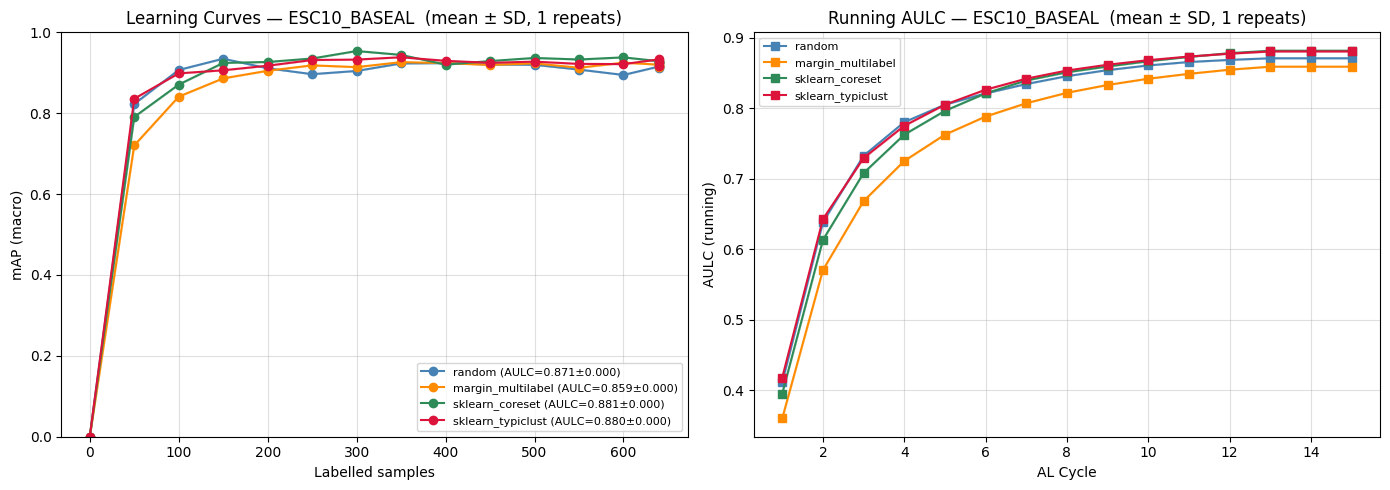


Final results — ESC10_BASEAL  (1 outer repeats)
Strategy                             mAP (mean±SD)      AULC (mean±SD)
------------------------------------------------------------------------
random                          0.9116 ±0.0000  0.8706 ±0.0000
margin_multilabel               0.9147 ±0.0000  0.8587 ±0.0000
sklearn_coreset                 0.9272 ±0.0000  0.8813 ±0.0000
sklearn_typiclust               0.9167 ±0.0000  0.8802 ±0.0000


In [6]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (strategy, histories), color in zip(results.items(), colors):
    agg = aggregate_histories(histories)

    n_labeled   = np.array([0]   + [a['n_labeled']    for a in agg])
    mAP_means   = np.array([0.0] + [a['mAP_mean']     for a in agg])
    mAP_sds     = np.array([0.0] + [a['mAP_sd']       for a in agg])
    aulc_means  = np.array([a['aulc_mAP_mean'] for a in agg])
    aulc_sds    = np.array([a['aulc_mAP_sd']  for a in agg])
    cycles      = np.arange(1, len(aulc_means) + 1)

    final_aulc_mean = agg[-1]['aulc_mAP_mean']
    final_aulc_sd   = agg[-1]['aulc_mAP_sd']
    label = f"{strategy} (AULC={final_aulc_mean:.3f}±{final_aulc_sd:.3f})"

    # mAP learning curve
    axes[0].plot(n_labeled, mAP_means, marker='o', color=color, label=label)
    axes[0].fill_between(n_labeled,
                         mAP_means - mAP_sds,
                         mAP_means + mAP_sds,
                         alpha=0.2, color=color)

    # Running AULC curve
    axes[1].plot(cycles, aulc_means, marker='s', color=color, label=strategy)
    axes[1].fill_between(cycles,
                         aulc_means - aulc_sds,
                         aulc_means + aulc_sds,
                         alpha=0.2, color=color)

axes[0].set_xlabel('Labelled samples')
axes[0].set_ylabel('mAP (macro)')
axes[0].set_title(f'Learning Curves — {DATASET_NAME}  (mean ± SD, {N_REPEATS} repeats)')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('AULC (running)')
axes[1].set_title(f'Running AULC — {DATASET_NAME}  (mean ± SD, {N_REPEATS} repeats)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nFinal results — {DATASET_NAME}  ({N_REPEATS} outer repeats)")
print(f"{'Strategy':<30}  {'mAP (mean±SD)':>18}  {'AULC (mean±SD)':>18}")
print("-" * 72)
for strategy, histories in results.items():
    agg = aggregate_histories(histories)
    final = agg[-1]
    print(f"{strategy:<30}  {final['mAP_mean']:>6.4f} ±{final['mAP_sd']:>6.4f}  "
          f"{final['aulc_mAP_mean']:>6.4f} ±{final['aulc_mAP_sd']:>6.4f}")

## Step 5: Exported files

Each strategy's results are written to `results/baselines/` as a YAML file.
Inspect these to determine an appropriate `MAX_BUDGET` and confirm baseline performance.

In [7]:
import yaml
from datetime import datetime

_BASELINE_EPOCHS     = 10
_BASELINE_BATCH_SIZE = 32


def export_aggregated(strategy, histories, learner, output_path, max_budget=None):
    """
    Export aggregated (mean ± SD across outer repeats) results as a YAML file.

    The per-cycle learning curve contains mAP and AULC mean/SD.
    Supplementary fields include total annotation cost and sampling wall-time
    (mean ± SD across repeats) and the standard computational cost ratio.
    """
    agg = aggregate_histories(histories)
    model_parameters = int(sum(p.numel() for p in learner.model.parameters()))
    n_cycles = len(agg)
    epochs_per_cycle = EPOCHS_PER_CYCLE

    # Per-cycle rows
    learning_curve = []
    for a in agg:
        learning_curve.append({
            'cycle':                 a['cycle'],
            'n_labeled':             a['n_labeled'],
            'mAP_mean':              round(a['mAP_mean'],          6),
            'mAP_sd':                round(a['mAP_sd'],            6),
            'aulc_mAP_mean':         round(a['aulc_mAP_mean'],     6),
            'aulc_mAP_sd':           round(a['aulc_mAP_sd'],       6),
            'annotation_cost':       a['annotation_cost'],
            'sampling_time_s_mean':  round(a['sampling_time_s_mean'], 6),
            'sampling_time_s_sd':    round(a['sampling_time_s_sd'],   6),
        })

    # Aggregate annotation cost and sampling time across repeats
    total_ann_costs = [
        sum(h[c].get('annotation_cost', 0) for c in range(n_cycles))
        for h in histories
    ]
    total_stimes = [
        sum(h[c].get('sampling_time_s', 0.0) for c in range(n_cycles))
        for h in histories
    ]

    # Computational cost
    baseline_n_cycles = max_budget // _BASELINE_BATCH_SIZE if max_budget else n_cycles
    cost_method   = model_parameters * epochs_per_cycle * n_cycles
    baseline_cost = model_parameters * _BASELINE_EPOCHS * baseline_n_cycles
    relative_cost = round(cost_method / baseline_cost, 4) if baseline_cost > 0 else None

    submission = {
        'submission_timestamp':   datetime.now().isoformat(timespec='seconds'),
        'author_lastname':        AUTHOR_LASTNAME,
        'institute_abbreviation': INSTITUTE_ABBREVIATION,
        'sampling_strategy':      strategy,
        'dataset':                DATASET_NAME,
        'model':                  MODEL_NAME,
        'config': {
            'learning_rate':      learner.learning_rate,
            'model_parameters':   model_parameters,
            'n_outer_repeats':    N_REPEATS,
            'pretrain_samples':   learner.pretrain_samples,
        },
        'learning_curve': learning_curve,
        'supplementary': {
            'n_cycles':                       n_cycles,
            'n_outer_repeats':                N_REPEATS,
            'total_annotation_cost_mean':     round(float(np.mean(total_ann_costs)), 2),
            'total_annotation_cost_sd':       round(float(np.std(total_ann_costs)),  2),
            'total_sampling_time_s_mean':     round(float(np.mean(total_stimes)),    6),
            'total_sampling_time_s_sd':       round(float(np.std(total_stimes)),     6),
            'computational_cost': {
                'model_parameters':   model_parameters,
                'epochs_per_cycle':   epochs_per_cycle,
                'n_cycles':           n_cycles,
                'cost_method':        cost_method,
                'baseline_n_cycles':  baseline_n_cycles,
                'baseline_cost':      baseline_cost,
                'relative_cost':      relative_cost,
            },
        },
    }

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        yaml.dump(submission, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
    print(f"  Saved: {Path(output_path).name}")


print(f"Files saved to: {PROJECT_ROOT / 'results' / 'baselines'}\n")
for strategy in STRATEGIES:
    safe_name = DATASET_NAME.replace('/', '_')
    output_file = OUTPUT_DIR / f"{strategy}_{safe_name}.yaml"
    export_aggregated(
        strategy=strategy,
        histories=results[strategy],
        learner=all_learners[strategy],
        output_path=str(output_file),
        max_budget=MAX_BUDGET,
    )

Files saved to: c:\Users\bmcewen\Documents\GitHub\BaseAL\results\baselines

  Saved: random_ESC10_BASEAL.yaml
  Saved: margin_multilabel_ESC10_BASEAL.yaml
  Saved: sklearn_coreset_ESC10_BASEAL.yaml
  Saved: sklearn_typiclust_ESC10_BASEAL.yaml


## Notes

- `MAX_BUDGET = None` — the loop runs for exactly `N_CYCLES × N_SAMPLES_PER_CYCLE` samples with no cap.
  Set `MAX_BUDGET` to a specific value once an appropriate budget has been determined from these results.
- All four strategies use the same `learning_rate`, `epochs`, and `batch_size` to ensure fair comparison.
- The YAML exports in `results/baselines/` contain the full learning curve and can be used to set
  `MAX_BUDGET` in the challenge participant notebooks.